## Initial conditions: Yj varies, tanh bathymetry (test228–test239)

**Settings:**
- Resolution: dx = dy = **300 m**
- Domain: Lx = 500 km, Ly = 400 km
- Ljet = 5 km, U = 0.2 m/s
- Slope width: 55 km (tanh), slope height: 400 m, shelf: 100 m, basin: 500 m
- Slope centred at Ys = 200 km → slope spans ~172.5 to ~227.5 km

**What varies:** jet centre Yj
- test258: Yj = 150.0 km — flat shelf (~100 m)
- test259–268: Yj steps across the slope (172.5 to 227.5 km, step ~5.6 km)
- test269: Yj = 250.0 km — flat basin (~500 m)

| Test | Yj (km) | Depth at Yj (m) |
|------|---------|----------------|
| test228 | 150.000 | ~102 (flat shelf) |
| test229 | 172.500 | ~120 |
| test230 | 178.611 | ~137 |
| test231 | 184.722 | ~165 |
| test232 | 190.833 | ~210 |
| test233 | 196.944 | ~268 |
| test234 | 203.056 | ~331 |
| test235 | 209.167 | ~392 |
| test236 | 215.278 | ~435 |
| test237 | 221.389 | ~463 |
| test238 | 227.500 | ~480 |
| test239 | 250.000 | ~498 (flat basin) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os

### Domain and physical constants

In [2]:
# Domain
Lx = 500e3    # m
Ly = 400e3    # m
dx = 300      # m
dy = 300      # m
nx = int(Lx / dx)   # 1666
ny = int(Ly / dy)   # 1333
nxp = nx + 1
nyp = ny + 1

xh = np.linspace(dx/2, nx*dx - dx/2, nx)
yh = np.linspace(dy/2, ny*dy - dy/2, ny)
xq = np.linspace(0, nx*dx, nxp)
yq = np.linspace(0, ny*dy, nyp)

# Physical constants
f = -1e-5   # s^-1
g = 9.81    # m s^-2

# Velocity (fixed)
Ljet = 5e3    # m  (5 km)
U    = 0.20   # m s^-1

# Bathymetry (fixed)
shallow_depth  = 100.0   # m
deep_depth     = 500.0   # m
slope_width_km = 55.0    # km
Ys             = Ly / 2  # m  slope centre (200 km)

# Tanh steepness: 90% of depth change within slope_width_km
steepness = (slope_width_km * 1e3) / (2 * np.arctanh(0.95))

print(f'Grid: nx={nx}, ny={ny}  |  {Lx/1e3:.0f} x {Ly/1e3:.0f} km  |  dx={dx} m')
print(f'Slope: {slope_width_km:.0f} km wide, centred at {Ys/1e3:.0f} km  |  steepness={steepness:.1f} m')

Grid: nx=1666, ny=1333  |  500 x 400 km  |  dx=300 m
Slope: 55 km wide, centred at 200 km  |  steepness=15012.7 m


### Helper functions

In [3]:
def make_fields(Yj):
    """Compute velocity and eta fields for a given jet centre Yj."""
    Xq_, Yh_u = np.meshgrid(xq, yh)
    Xh_, Yh_h = np.meshgrid(xh, yh)
    yprime_u = (Yh_u - Yj) / Ljet
    yprime_h = (Yh_h - Yj) / Ljet

    u_clean = U * np.tanh(yprime_u)
    v       = np.zeros((nyp, nx))

    rng    = np.random.default_rng(seed=42)
    noise  = rng.standard_normal(u_clean.shape)
    decay  = 1.0 / np.cosh(yprime_u)**2
    u      = u_clean + 1e-3 * decay * noise

    eta_t  = -(f * U * Ljet / g) * np.log(np.cosh(yprime_h))
    eta_t -= eta_t.mean()
    return u, v, eta_t


# Bathymetry is identical for all experiments — compute once
bathy_profile = shallow_depth + (deep_depth - shallow_depth) * \
                (np.tanh((yh - Ys) / steepness) + 1) / 2
bathy_2d = np.tile(bathy_profile[:, np.newaxis], (1, nx))


def write_netcdf(input_dir, u, v, eta_t, depth_2d):
    """Write init_vel.nc, init_eta.nc, ocean_topog.nc."""
    zl = 1
    z  = np.array([-250.0])
    u_3d = u    [np.newaxis, :, :]
    v_3d = v    [np.newaxis, :, :]
    h_3d = eta_t[np.newaxis, :, :]

    # init_vel.nc
    nc = Dataset(os.path.join(input_dir, 'init_vel.nc'), 'w', format='NETCDF4')
    nc.createDimension('zl', zl) ; nc.createDimension('yh', ny)
    nc.createDimension('xh', nx) ; nc.createDimension('yq', nyp)
    nc.createDimension('xq', nxp)
    v0=nc.createVariable('zl','f4',('zl',));  v0[:]=z
    v0.axis='Z'; v0.long_name='depth to layer'
    v0=nc.createVariable('xh','f4',('xh',)); v0[:]=xh
    v0.axis='X'; v0.long_name='h-point longitude'; v0.units='meters'
    v0=nc.createVariable('yh','f4',('yh',)); v0[:]=yh
    v0.axis='Y'; v0.long_name='h-point latitude';  v0.units='meters'
    v0=nc.createVariable('xq','f4',('xq',)); v0[:]=xq
    v0.axis='X'; v0.long_name='q-point longitude'; v0.units='meters'
    v0=nc.createVariable('yq','f4',('yq',)); v0[:]=yq
    v0.axis='Y'; v0.long_name='q-point latitude';  v0.units='meters'
    uv=nc.createVariable('u','f4',('zl','yh','xq')); uv[:]=u_3d
    uv.units='m s-1'; uv.long_name='Eastward velocity'
    uv.standard_name='eastward_sea_water_velocity'
    vv=nc.createVariable('v','f4',('zl','yq','xh')); vv[:]=v_3d
    vv.units='m s-1'; vv.long_name='Northward velocity'
    vv.standard_name='northward_sea_water_velocity'
    nc.regrid_method='bilinear'; nc.close()

    # init_eta.nc
    nc = Dataset(os.path.join(input_dir, 'init_eta.nc'), 'w', format='NETCDF4')
    nc.createDimension('yh', ny); nc.createDimension('xh', nx)
    v0=nc.createVariable('xh','f4',('xh',)); v0[:]=xh
    v0.axis='X'; v0.long_name='h-point longitude'; v0.units='meters'
    v0=nc.createVariable('yh','f4',('yh',)); v0[:]=yh
    v0.axis='Y'; v0.long_name='h-point latitude';  v0.units='meters'
    hv=nc.createVariable('eta_t','f4',('yh','xh')); hv[:]=h_3d
    hv.units='m'; hv.long_name='Free surface height anomaly'
    hv.standard_name='sea_floor_depth_below_sea_surface'; nc.close()

    # ocean_topog.nc
    nc = Dataset(os.path.join(input_dir, 'ocean_topog.nc'), 'w', format='NETCDF4')
    nc.createDimension('yh', ny); nc.createDimension('xh', nx)
    v0=nc.createVariable('xh','f4',('xh',)); v0[:]=xh
    v0.long_name='t-cell center x-location'; v0.units='meters'
    v0=nc.createVariable('yh','f4',('yh',)); v0[:]=yh
    v0.long_name='t-cell center y-location'; v0.units='meters'
    dv=nc.createVariable('depth','f4',('yh','xh')); dv[:]=depth_2d
    dv.units='m'; dv.long_name='ocean bottom depth'
    dv.standard_name='sea_floor_depth_below_geoid'; nc.close()

### Experiment definitions

In [4]:
base_dir = '/scratch/nm03/ae7501/mom6_input_directories/idealized'

# 12 Yj values:
# - test258: flat shelf (150 km)
# - test259-268: evenly spread across slope (172.5 to 227.5 km, step ~5.6 km)
# - test269: flat basin (250 km)
Yj_values_km = [150.0] + list(np.linspace(172.5, 227.5, 10)) + [250.0]

experiments = [
    dict(exp_num=228+i, Yj=yj*1e3, Yj_km=yj)
    for i, yj in enumerate(Yj_values_km)
]

# Print Yj values and depth at each Yj location
print(f'12 experiments: test{experiments[0]["exp_num"]} – test{experiments[-1]["exp_num"]}')
print(f'{"Test":<8} {"Yj (km)":<12} {"depth at Yj (m)"}')
print('-' * 40)
for exp in experiments:
    idx = np.argmin(np.abs(yh - exp['Yj']))
    depth_at_yj = bathy_profile[idx]
    print(f'test{exp["exp_num"]:<4} {exp["Yj_km"]:<12.3f} {depth_at_yj:.2f} m')

12 experiments: test228 – test239
Test     Yj (km)      depth at Yj (m)
----------------------------------------
test228  150.000      100.50 m
test229  172.500      109.81 m
test230  178.611      121.99 m
test231  184.722      145.83 m
test232  190.833      192.19 m
test233  196.944      259.92 m
test234  203.056      338.80 m
test235  209.167      409.69 m
test236  215.278      453.63 m
test237  221.389      477.73 m
test238  227.500      490.06 m
test239  250.000      499.49 m


### Main loop

In [5]:
for exp in experiments:
    exp_name  = f'test{exp["exp_num"]}'
    input_dir = os.path.join(base_dir, exp_name, 'INPUT')
    os.makedirs(input_dir, exist_ok=True)

    # Velocity fields recomputed for each Yj (all different)
    u, v, eta_t = make_fields(exp['Yj'])

    # Bathymetry is identical for all experiments
    write_netcdf(input_dir, u, v, eta_t, bathy_2d)

    idx = np.argmin(np.abs(yh - exp['Yj']))
    print(f"{exp_name}: Yj={exp['Yj_km']:.3f}km  depth_at_Yj={bathy_profile[idx]:.1f}m")

print(f"\n{'='*60}\nDone. {len(experiments)} experiments written.\n{'='*60}")

test228: Yj=150.000km  depth_at_Yj=100.5m
test229: Yj=172.500km  depth_at_Yj=109.8m
test230: Yj=178.611km  depth_at_Yj=122.0m
test231: Yj=184.722km  depth_at_Yj=145.8m
test232: Yj=190.833km  depth_at_Yj=192.2m
test233: Yj=196.944km  depth_at_Yj=259.9m
test234: Yj=203.056km  depth_at_Yj=338.8m
test235: Yj=209.167km  depth_at_Yj=409.7m
test236: Yj=215.278km  depth_at_Yj=453.6m
test237: Yj=221.389km  depth_at_Yj=477.7m
test238: Yj=227.500km  depth_at_Yj=490.1m
test239: Yj=250.000km  depth_at_Yj=499.5m

Done. 12 experiments written.


### check plot

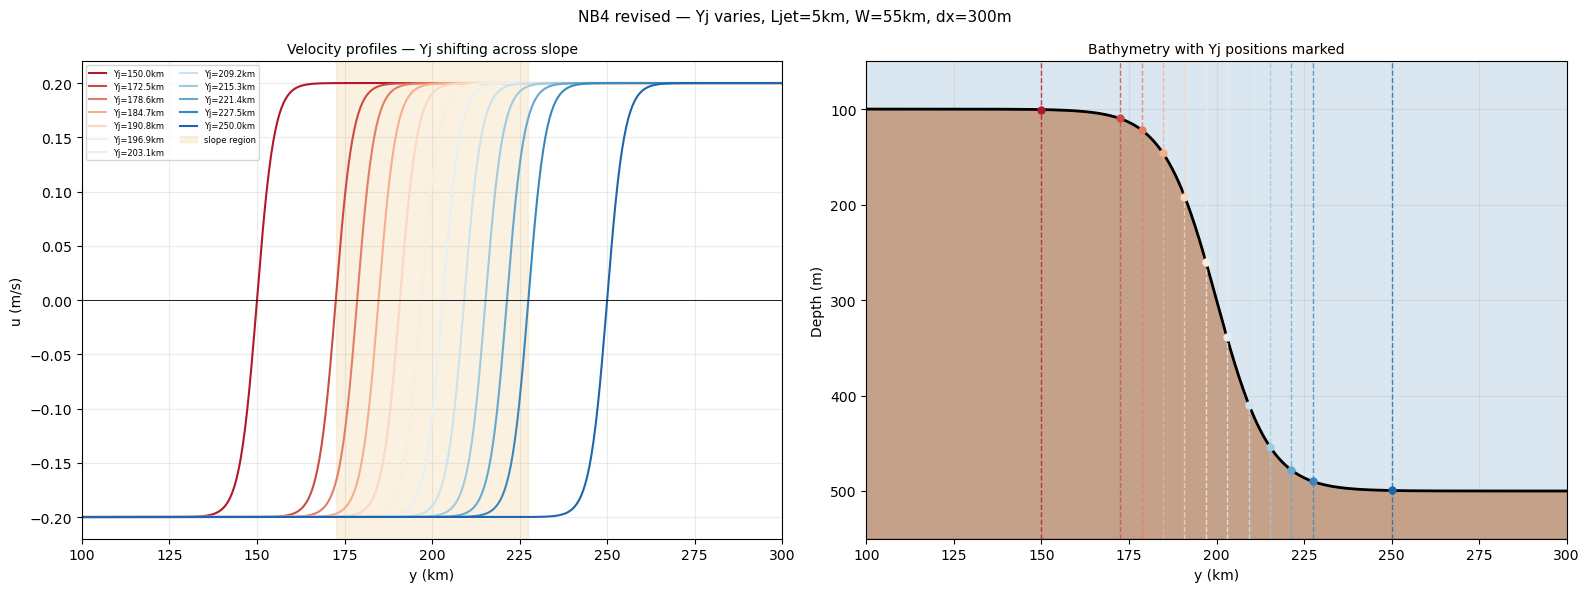

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.RdBu(np.linspace(0.1, 0.9, len(experiments)))

# Left: velocity profiles
ax = axes[0]
for i, exp in enumerate(experiments):
    yprime = (yh - exp['Yj']) / Ljet
    u_1d   = U * np.tanh(yprime)
    ax.plot(yh/1e3, u_1d, color=colors[i], lw=1.5,
            label=f'Yj={exp["Yj_km"]:.1f}km')
ax.axvspan((Ys - slope_width_km*1e3/2)/1e3,
           (Ys + slope_width_km*1e3/2)/1e3,
           color='wheat', alpha=0.4, label='slope region')
ax.axhline(0, color='k', lw=0.6)
ax.set_xlim(100, 300)
ax.set_xlabel('y (km)', fontsize=10)
ax.set_ylabel('u (m/s)', fontsize=10)
ax.set_title('Velocity profiles — Yj shifting across slope', fontsize=10)
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.25)

# Right: bathymetry with Yj markers
ax = axes[1]
ax.fill_between(yh/1e3, 0, bathy_profile, color='steelblue', alpha=0.2)
ax.fill_between(yh/1e3, bathy_profile, 550, color='saddlebrown', alpha=0.5)
ax.plot(yh/1e3, bathy_profile, 'k', lw=2)
for i, exp in enumerate(experiments):
    idx = np.argmin(np.abs(yh - exp['Yj']))
    ax.axvline(exp['Yj_km'], color=colors[i], lw=1, ls='--', alpha=0.8)
    ax.plot(exp['Yj_km'], bathy_profile[idx], 'o',
            color=colors[i], ms=5, zorder=5)
ax.set_xlim(100, 300)
ax.set_ylim(50, 550)
ax.invert_yaxis()
ax.set_xlabel('y (km)', fontsize=10)
ax.set_ylabel('Depth (m)', fontsize=10)
ax.set_title('Bathymetry with Yj positions marked', fontsize=10)
ax.grid(True, alpha=0.25)

plt.suptitle('NB4 revised — Yj varies, Ljet=5km, W=55km, dx=300m', fontsize=11)
plt.tight_layout()
plt.show()